In [72]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scipy.stats as stats

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"

df = pd.read_csv(url)
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='str')

In [73]:
df.sample(18)

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
19939,371013,Ivor,Pandur,Ivor Pandur,2023,385,ivor-pandur,Croatia,Rijeka,Croatia,...,right,187.0,2027-06-30 00:00:00,GAMMA SPORT,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/ivor-pandur/pr...,NL1,Fortuna Sittardia Combinatie,2000000.0,2000000.0
5860,67080,Víctor,Laguardia,Víctor Laguardia,2021,1108,victor-laguardia,Spain,Zaragoza,Spain,...,right,183.0,2024-06-30 00:00:00,Bahía Internacional,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/victor-laguard...,ES1,Deportivo Alavés S.A.D.,800000.0,10000000.0
7342,91698,Oleksandr,Churilov,Oleksandr Churilov,2014,6993,oleksandr-churilov,UdSSR,"Mariupol, Donetsk Region",Ukraine,...,NaN,189.0,2023-06-30 00:00:00,Valiachmetov,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/oleksandr-chur...,UKR1,FK Mariupol,50000.0,300000.0
4814,55997,José María,Basanta,José María Basanta,2015,430,jose-maria-basanta,Argentina,Buenos Aires,Argentina,...,left,188.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/jose-maria-bas...,IT1,Associazione Calcio Fiorentina,500000.0,3500000.0
1557,18547,Ali,Turan,Ali Turan,2019,2293,ali-turan,Turkey,Kayseri,Turkey,...,right,186.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/ali-turan/prof...,TR1,Konyaspor,75000.0,3500000.0
8217,110326,NaN,Jucilei,Jucilei,2013,2700,jucilei,Brazil,São Gonçalo,Brazil,...,right,186.0,NaN,ARF Assessoria,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/jucilei/profil...,RU1,Anzhi Makhachkala ( -2022),250000.0,11000000.0
4137,47659,Costel,Pantilimon,Costel Pantilimon,2020,833,costel-pantilimon,Romania,Bacău,Romania,...,right,203.0,NaN,Darren Dein,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/costel-pantili...,TR1,Denizlispor,250000.0,6000000.0
12804,204070,Paolo,Sokoli,Paolo Sokoli,2013,252,paolo-sokoli,Albania,Velipojë,Albania,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/paolo-sokoli/p...,IT1,Genoa Cricket and Football Club,50000.0,50000.0
31456,987480,Aleksandr,Deryugin,Aleksandr Deryugin,2023,41231,aleksandr-deryugin,Russia,"Pavlovskaya, Krasnodar Region",Russia,...,left,179.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/aleksandr-dery...,RU1,FC Sochi,50000.0,50000.0
23032,468873,Erkebulan,Seydakhmet,Erkebulan Seydakhmet,2018,28095,erkebulan-seydakhmet,Kazakhstan,Taraz,Kazakhstan,...,right,178.0,2023-12-31 00:00:00,Dmitriy Seluk,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/erkebulan-seyd...,RU1,FK Ufa,250000.0,400000.0


In [74]:
df = df[["name", "position", "date_of_birth", "height_in_cm"]]
df.head(5)

,name,position,date_of_birth,height_in_cm
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0
2,Dimitar Berbatov,Attack,1981-01-30 00:00:00,NaN
3,Lúcio,Defender,1978-05-08 00:00:00,NaN
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0


In [75]:
df["month"] = pd.to_datetime(df["date_of_birth"]).dt.month
df.head(5)

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
2,Dimitar Berbatov,Attack,1981-01-30 00:00:00,NaN,1.0
3,Lúcio,Defender,1978-05-08 00:00:00,NaN,5.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0


In [76]:
df = df.dropna(subset = ["height_in_cm"])
df = df.loc[df["height_in_cm"] > 150]
df.head()

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0
7,Tomas Rosicky,Midfield,1980-10-04 00:00:00,179.0,10.0
8,Marc Ziegler,Goalkeeper,1976-06-13 00:00:00,193.0,6.0


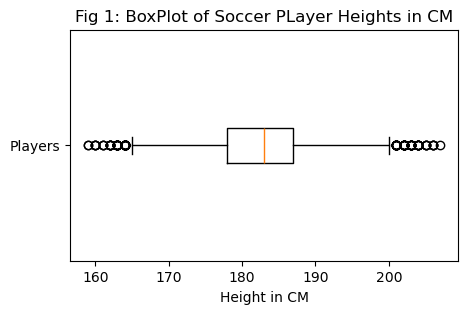

In [77]:
plt.figure(figsize= (5,3))
plt.boxplot(x = df["height_in_cm"], orientation = "horizontal")
plt.title("Fig 1: BoxPlot of Soccer PLayer Heights in CM")
plt.xlabel("Height in CM")
plt.yticks(ticks = [1], labels = ["Players"])
plt.show()

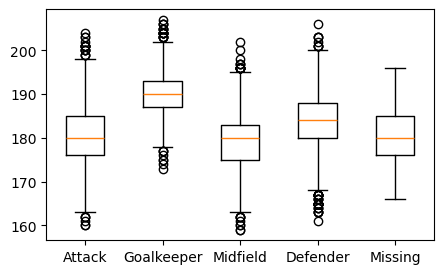

In [78]:
plt.figure(figsize = (5, 3))
pos = df["position"].unique()
data = [df.loc[df["position"] == p, "height_in_cm"] for p in pos]
plt.boxplot(x = data)
plt.xticks(ticks= range(1,len(pos)+ 1), labels = pos)
plt.show()

In [79]:
def boxplots(df: pd.DataFrame, y:str, x: str, title: str="", ylabel: str=""):
    plt.figure(figsize = (5,3))
    hts_box = sns.boxplot(data = df, y = y, x = x)
    hts_box.set(
        title = title,
        ylabel = ylabel)
    plt.axhline(df[y].mean(), label = "Mean", linestyle = "--", color = "red")
    plt.show()

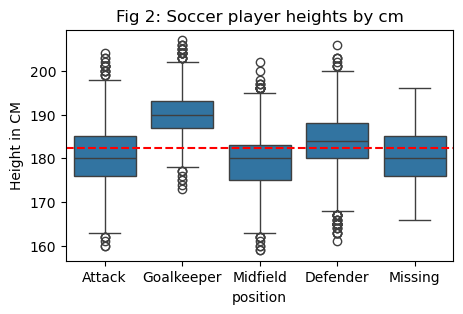

In [80]:
boxplots(df= df, x = "position", y = "height_in_cm", title = "Fig 2: Soccer player heights by cm", ylabel = "Height in CM")

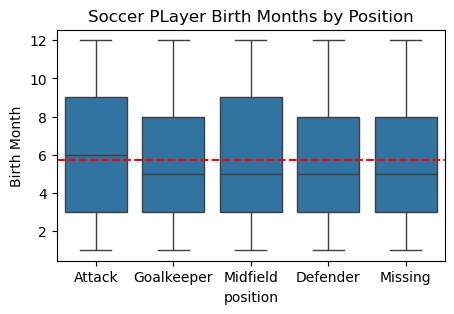

In [81]:
boxplots( df = df, x = "position", y = "month", title = "Soccer PLayer Birth Months by Position", ylabel = "Birth Month")

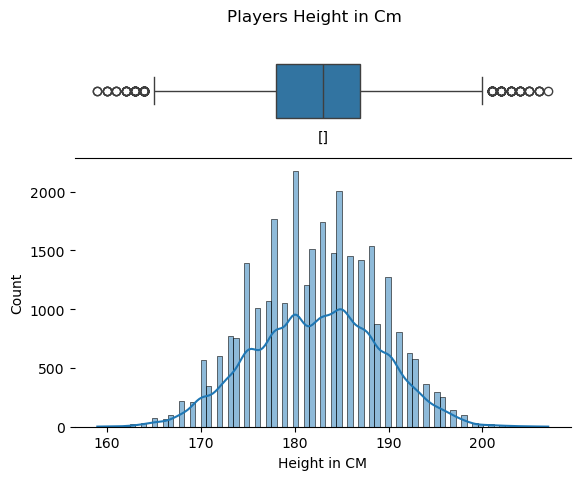

In [85]:
def generate_multiplot(df:pd.DataFrame, col:str, xlabel:str="", title:str=""):
    fig, (ax1, ax2) = plt.subplots(nrows =2, ncols = 1, height_ratios = [2,8])
    box = sns. boxplot(data = df, x= col, ax=ax1)
    hist = sns.histplot(data= df, x=col, ax=ax2, kde = True)
    box.set(yticks =[], xticks =[], xlabel = [])
    hist.set(xlabel = xlabel)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    fig.suptitle(title)
    
generate_multiplot(df=df, col = "height_in_cm", xlabel = "Height in CM", title = "Players Height in Cm")

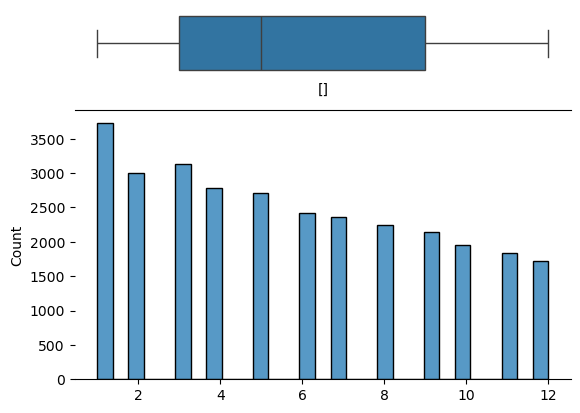

In [84]:
generate_multiplot(df = df, col = "month")